In [1]:
# Общие настройки
import os, math, random, re, json, time
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5,3)

import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer as SkTFIDF


RNG_SEED = 42
def set_seed(seed=RNG_SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()

# viz helpers
def plot_curve(values, title, ylabel="score", xlabel="step"):
    xs = np.arange(1, len(values)+1)
    plt.plot(xs, values, marker="o")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(True)
    plt.show()

def plot_confusion(cm, labels):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels, ylabel='True', xlabel='Pred')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout(); plt.show()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Задача: Seq2Seq RNN + собственный attention

**Задача:** Научить Seq2Seq-модель с вниманием приводить даты из разных «живых» записей к единому каноническому виду ISO (YYYY-MM-DD).

**Решение:** BiGRU encoder + GRUCell decoder + Bahdanau attention + masking

**Примеры входов:** "28 Jan 1999", "Jan 28, 1999", "1999/01/28", "28/01/1999", "01-28-1999 ", "19990128", "1st of February, 2004", " 07.03.1998 ".

**Результаты:** Exact Match на val/test + примеры

**Bonus:** Greedy vs Beam search

**TL;DR:** 

EM val = 0.991

Greedy 0.9908 → Beam5 0.9910

In [2]:
# ====== Генератор дат ======
import random, re, math
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

MONTHS_EN_S = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
MONTHS_EN_L = ["January","February","March","April","May","June","July","August","September","October","November","December"]
ORD = {1:"st",2:"nd",3:"rd"}
def ord_suffix(d):
    return ORD.get(d if d not in (11,12,13) else 0, "th")  # 11/12/13 → th

def noise_spaces(s):
    # случайные лишние пробелы/запятые
    s = re.sub(r"\s+", " ", s.strip())
    if random.random() < 0.3: s = " " * random.randint(1,2) + s
    if random.random() < 0.3: s = s + " " * random.randint(1,2)
    if random.random() < 0.2: s = s.replace(" ", "  ")
    return s

def render_any_date():
    """Возвращает (src, tgt, meta) где tgt=YYYY-MM-DD, meta: dict(fmt, locale, kind)"""
    y = random.randint(1970, 2030)
    m = random.randint(1, 12)
    d = random.randint(1, 28)
    tgt = f"{y:04d}-{m:02d}-{d:02d}"

    fmt = random.choice([
        "iso_dash", "iso_slash", "eu_slash", "eu_dot", "us_dash", "us_slash",
        "compact", "text_short", "text_long", "text_ord"
    ])

    locale = None
    if fmt in {"eu_slash","eu_dot"}:       # DD/MM/YYYY или DD.MM.YYYY
        src = f"{d:02d}/{m:02d}/{y:04d}" if fmt=="eu_slash" else f"{d:02d}.{m:02d}.{y:04d}"
        locale = "EU"
    elif fmt in {"us_dash","us_slash"}:     # MM-DD-YYYY или MM/DD/YYYY
        src = f"{m:02d}-{d:02d}-{y:04d}" if fmt=="us_dash" else f"{m:02d}/{d:02d}/{y:04d}"
        locale = "US"
    elif fmt == "iso_dash":                 # YYYY-MM-DD
        src = f"{y:04d}-{m:02d}-{d:02d}"
        locale = "ISO"
    elif fmt == "iso_slash":                # YYYY/MM/DD
        src = f"{y:04d}/{m:02d}/{d:02d}"
        locale = "ISO"
    elif fmt == "compact":                  # YYYYMMDD
        src = f"{y:04d}{m:02d}{d:02d}"
        locale = "ISO"
    elif fmt == "text_short":               # 28 Jan 1999
        src = f"{d:02d} {MONTHS_EN_S[m-1]} {y:04d}"
        locale = "EN"
    elif fmt == "text_long":                # January 28, 1999
        src = f"{MONTHS_EN_L[m-1]} {d}, {y:04d}"
        locale = "EN"
    elif fmt == "text_ord":                 # 1st of February, 2004
        suf = ord_suffix(d)
        src = f"{d}{suf} of {MONTHS_EN_L[m-1]}, {y:04d}"
        locale = "EN"
    else:
        raise ValueError(fmt)

    kind = "numeric" if fmt in {"eu_slash","eu_dot","us_dash","us_slash","iso_dash","iso_slash","compact"} else "text"
    if kind == "numeric" and locale in {"US","EU"} and random.random() < 0.8:
        src = src + " " + f"<{locale}>"

    src = noise_spaces(src)
    return src, tgt, {"fmt": fmt, "locale": locale, "kind": kind}

def make_pairs_any(n=120_000):
    return [render_any_date() for _ in range(n)]


In [3]:
# ====== Построение датасета (символы + спец токены) ======
PAD, SOS, EOS = 0, 1, 2

pairs_any = make_pairs_any(120_000)

src_texts = [s for s,_,_ in pairs_any]
tgt_texts = [t for _,t,_ in pairs_any]
meta_list = [m for _,_,m in pairs_any]

# алфавит из данных + спец-символы
alphabet = sorted(set("".join(src_texts + tgt_texts)))
chars = ["<pad>","<s>","</s>"] + alphabet
stoi = {c:i for i,c in enumerate(chars)}
itos = {i:c for c,i in stoi.items()}

def encode_str(s): return [stoi[c] for c in s]
def decode_ids(ids): return "".join(itos[int(i)] for i in ids if int(i) not in (PAD,SOS,EOS))

SRC_MAXLEN = max(len(s) for s in src_texts)            # переменная длина из-за разных форматов/шумов
TGT_LEN    = 10                                        # "YYYY-MM-DD"
TGT_MAXLEN_IN, TGT_MAXLEN_OUT = TGT_LEN+1, TGT_LEN+1   # <s>+tgt  | tgt+</s>

def encode_batch_var(texts, max_len):
    X = torch.full((len(texts), max_len), PAD, dtype=torch.long)
    L = torch.zeros(len(texts), dtype=torch.long)
    for i,s in enumerate(texts):
        ids = encode_str(s)[:max_len]
        X[i,:len(ids)] = torch.tensor(ids, dtype=torch.long)
        L[i] = len(ids)
    return X, L

def make_dataset_any(pairs, metas):
    src = [s for s,_,_ in pairs]
    tgt = [t for _,t,_ in pairs]
    Xsrc, Lsrc = encode_batch_var(src, SRC_MAXLEN)
    Yin  = torch.full((len(tgt), TGT_MAXLEN_IN), PAD, dtype=torch.long)
    Yout = torch.full((len(tgt), TGT_MAXLEN_OUT), PAD, dtype=torch.long)
    for i, t in enumerate(tgt):
        ids = encode_str(t)
        Yin[i,  :1+len(ids)] = torch.tensor([SOS] + ids, dtype=torch.long)
        Yout[i, :1+len(ids)] = torch.tensor(ids + [EOS], dtype=torch.long)
    return Xsrc, Lsrc, Yin, Yout, metas

# сплиты
N = len(pairs_any)
idx = np.random.permutation(N)
tr, va, te = idx[:int(.8*N)], idx[int(.8*N):int(.9*N)], idx[int(.9*N):]
train_pairs = [pairs_any[i] for i in tr];   train_meta = [meta_list[i] for i in tr]
val_pairs   = [pairs_any[i] for i in va];   val_meta   = [meta_list[i] for i in va]
test_pairs  = [pairs_any[i] for i in te];   test_meta  = [meta_list[i] for i in te]

Xsrc_tr, Lsrc_tr, Yin_tr, Yout_tr, meta_tr = make_dataset_any(train_pairs, train_meta)
Xsrc_va, Lsrc_va, Yin_va, Yout_va, meta_va = make_dataset_any(val_pairs,   val_meta)
Xsrc_te, Lsrc_te, Yin_te, Yout_te, meta_te = make_dataset_any(test_pairs,  test_meta)

train_ds = TensorDataset(Xsrc_tr, Lsrc_tr, Yin_tr, Yout_tr)
val_ds   = TensorDataset(Xsrc_va, Lsrc_va, Yin_va, Yout_va)
test_ds  = TensorDataset(Xsrc_te, Lsrc_te, Yin_te, Yout_te)

print("Vocab:", len(chars), "| SRC_MAXLEN:", SRC_MAXLEN)
assert stoi["<pad>"]==PAD and stoi["<s>"]==SOS and stoi["</s>"]==EOS
assert (Yout_tr!=PAD).any(), "targets became all PAD"


Vocab: 50 | SRC_MAXLEN: 34


In [4]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim=128):
        super().__init__()
        self.We = nn.Linear(enc_dim, attn_dim, bias=False)
        self.Wd = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, enc_out, dec_h, mask=None):
        """
        enc_out: [B, S, enc_dim]  (S = длина source)
        dec_h:   [B, dec_dim]     (текущее скрытое состояние декодера)
        mask:    [B, S]           (True = валиден, False = pad)
        return: (context, weights)
          context: [B, enc_dim]
          weights: [B, S]  (softmax по S)
        """
        enc_pr = self.We(enc_out)
        dec_pr = self.Wd(dec_h).unsqueeze(1)

        e_ij = self.v(torch.tanh(enc_pr + dec_pr)).squeeze(-1)
        if mask is not None:
          e_ij.masked_fill_(~mask, torch.finfo(e_ij.dtype).min)

        a_ij = F.softmax(e_ij, dim=1)
        context = torch.sum(a_ij.unsqueeze(-1) * enc_out, dim=1)
        return context, a_ij

class Encoder(nn.Module):
    def __init__(self, V, emb=64, hid=128):
        """
        bidirectional GRU/LSTM. Выход хотим [B,S,hid] (одинаков с dec_dim для удобства).
        """
        super().__init__()
        self.hid = hid
        self.emb = emb
        self.embedding = nn.Embedding(V, emb)
        self.gru = nn.GRU(emb, hid, bidirectional=True, batch_first=True)
        self.proj = nn.Linear(2*hid, hid)


    def forward(self, x, lengths):
        """
        x: [B,S] (source ids), lengths: [B]
        return: enc_out [B,S,hid], enc_mask [B,S], h0_for_dec [B,hid]
        """
        embedded = self.embedding(x)
        # outputs, hidden = self.gru(embedded)
        packed = pack_padded_sequence(
          embedded,
          lengths.cpu(),
          batch_first=True,
          enforce_sorted=False
        )
        packed_out, hidden = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        out = self.proj(out)
        mask = (x!=PAD)
        h0_for_dec = self.proj(torch.cat([hidden[0], hidden[1]], dim=-1))
        return out, mask, h0_for_dec


class Decoder(nn.Module):
    def __init__(self, V, emb=64, hid=128, attn_dim=128):
        super().__init__()
        self.hid = hid
        self.emb = emb
        self.embedding = nn.Embedding(V, emb)
        self.gru = nn.GRUCell(emb+hid, hid)
        self.attention = BahdanauAttention(hid, hid, attn_dim)
        self.out = nn.Linear(2*hid, V) # лоигты

    def forward(self, y_inp, enc_out, enc_mask, h0, teacher_forcing=0.5, collect_attn=False):
        """
        y_inp:  [B, T]  (вход декодера: <s> + tgt)
        enc_out:[B, S, hid]
        enc_mask:[B, S] (True=valid)
        h0:     [B, hid] (инициализация декодера)
        return: (logits, attn_seq)
          logits: [B, T, V]
          attn_seq (optional): список из T элементов, каждый [B,S]
        """
        B, T = y_inp.shape
        dec_h = h0
        y_prev = y_inp[:,0]
        V = self.out.out_features

        logits = torch.zeros(B, T, V, device=y_inp.device)
        attn_seq = [] if collect_attn else None

        for t in range(T):
            emb_t = self.embedding(y_prev)
            context_t, alpha_t = self.attention(enc_out, dec_h, mask=enc_mask)

            if collect_attn:
                attn_seq.append(alpha_t.detach().cpu())

            rnn_inp = torch.cat([emb_t, context_t], dim=-1)
            dec_h = self.gru(rnn_inp, dec_h)

            logits_t = self.out(torch.cat([dec_h, context_t], dim=-1))
            logits[:, t, :] = logits_t

            if t + 1 < T:
                if teacher_forcing > 0 and torch.rand(1, device=y_inp.device).item() < teacher_forcing:
                    y_prev = y_inp[:, t + 1]
                else:
                    y_prev = logits_t.argmax(dim=-1)

        return logits, attn_seq

    def decode_step(self, y_last, enc_out, enc_mask, h):
      emb_t = self.embedding(y_last)
      context_t, alpha_t = self.attention(enc_out, h, mask=enc_mask)
      rnn_inp = torch.cat([emb_t, context_t], dim=-1)
      h_new = self.gru(rnn_inp, h)
      logits = self.out(torch.cat([h_new, context_t], dim=-1))
      return logits, h_new, alpha_t



class Seq2Seq(nn.Module):
    def __init__(self, V, emb=64, hid=128, attn_dim=128, cell="gru"):
        super().__init__()
        self.encoder = Encoder(V, emb=emb, hid=hid)
        self.decoder = Decoder(V, emb=emb, hid=hid, attn_dim=attn_dim)
    def encode(self, Xsrc, Lsrc):
        return self.encoder(Xsrc, Lsrc)  # enc_out, enc_mask, h0
    def decode_step(self, y_last, enc_out, enc_mask, h):
        return self.decoder.decode_step(y_last, enc_out, enc_mask, h)
    def forward(self, Xsrc, Lsrc, Yin, teacher_forcing=0.5, collect_attn=False):
        enc_out, enc_mask, h0 = self.encoder(Xsrc, Lsrc)
        return self.decoder(Yin, enc_out, enc_mask, h0, teacher_forcing, collect_attn)


In [5]:
# ===== Train / Eval / Viz =====
def _unpack_batch(batch):
    """Поддерживает и (Xsrc,Lsrc,Yin,Yout) и (Xsrc,Lsrc,Yin,Yout,Ltg)."""
    if len(batch) == 5:
        Xsrc, Lsrc, Yin, Yout, _ = batch
    elif len(batch) == 4:
        Xsrc, Lsrc, Yin, Yout = batch
    else:
        raise ValueError(f"Unexpected batch size: {len(batch)}")
    return Xsrc, Lsrc, Yin, Yout

def train_epoch(model, loader, opt, clip=1.0, tf_ratio=0.5):
    import torch.nn.functional as F
    model.train()
    losses = []
    for batch in loader:
        Xsrc, Lsrc, Yin, Yout = _unpack_batch(batch)
        Xsrc, Lsrc = Xsrc.to(DEVICE), Lsrc.to(DEVICE)
        Yin,  Yout = Yin.to(DEVICE),  Yout.to(DEVICE)
        opt.zero_grad()
        logits, _ = model(Xsrc, Lsrc, Yin, teacher_forcing=tf_ratio, collect_attn=False)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), Yout.view(-1), ignore_index=PAD)
        loss.backward()
        if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses))

def exact_match_accuracy(model, loader):
    model.eval()
    em_ok, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            Xsrc, Lsrc, Yin, Yout = _unpack_batch(batch)
            Xsrc, Lsrc = Xsrc.to(DEVICE), Lsrc.to(DEVICE)
            Yin,  Yout = Yin.to(DEVICE),  Yout.to(DEVICE)
            enc_out, enc_mask, h0 = model.encode(Xsrc, Lsrc)
            B = Xsrc.size(0)
            y = torch.full((B, 1), SOS, dtype=torch.long, device=DEVICE)
            outs = []
            for _ in range(TGT_MAXLEN_OUT):
                logits, h0, _ = model.decode_step(y[:, -1], enc_out, enc_mask, h0)
                nxt = logits.argmax(-1)
                outs.append(nxt.unsqueeze(1))
                y = torch.cat([y, nxt.unsqueeze(1)], dim=1)
            pred = torch.cat(outs, dim=1)                      # [B, T]
            match = (pred == Yout[:, :pred.size(1)]).all(dim=1)
            em_ok += int(match.sum().item()); total += B
    return em_ok / max(1, total)

def plot_curve(values, title, ylabel="loss"):
    xs = np.arange(1, len(values)+1)
    plt.plot(xs, values, marker="o"); plt.grid(True)
    plt.title(title); plt.xlabel("epoch"); plt.ylabel(ylabel); plt.show()


In [6]:
# ====== Обучение ======

BATCH= 256
EPOCHS= 10
LR= 1e-3

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

model = Seq2Seq(V=len(chars), emb=64, hid=128, attn_dim=128).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)

best_em, best_state = 0.0, None
train_losses, val_em = [], []
for ep in range(1, EPOCHS+1):
    tf_ratio = 0.6 + (0.2-0.6)*(ep-1)/(EPOCHS-1)  # линейный schedule TF 0.6→0.2
    tr = train_epoch(model, train_loader, opt, clip=1.0, tf_ratio=tf_ratio)
    em = exact_match_accuracy(model, val_loader)
    train_losses.append(tr); val_em.append(em)
    print(f"epoch {ep:02d} | tf={tf_ratio:.2f} | train {tr:.3f} | val EM {em:.4f}")
    if em>best_em:
        best_em=em; best_state={k:v.cpu() for k,v in model.state_dict().items()}
if best_state: model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
print("Test EM:", exact_match_accuracy(model, test_loader))


epoch 01 | tf=0.60 | train 0.486 | val EM 0.9889
epoch 02 | tf=0.56 | train 0.007 | val EM 0.9883
epoch 03 | tf=0.51 | train 0.005 | val EM 0.9918
epoch 04 | tf=0.47 | train 0.004 | val EM 0.9902
epoch 05 | tf=0.42 | train 0.003 | val EM 0.9916
epoch 06 | tf=0.38 | train 0.003 | val EM 0.9906
epoch 07 | tf=0.33 | train 0.004 | val EM 0.9900
epoch 08 | tf=0.29 | train 0.003 | val EM 0.9884
epoch 09 | tf=0.24 | train 0.003 | val EM 0.9912
epoch 10 | tf=0.20 | train 0.003 | val EM 0.9897
Test EM: 0.9903333333333333


In [7]:
# ====== Пер-форматные метрики ======
def em_per_group(model, pairs, metas, batch=256, group_key="fmt"):
    model.eval()
    ok = []
    for i in range(0, len(pairs), batch):
        chunk = pairs[i:i+batch]
        Xsrc, Lsrc, Yin, Yout, _ = make_dataset_any(chunk, metas[i:i+batch])
        Xsrc, Lsrc, Yin, Yout = Xsrc.to(DEVICE), Lsrc.to(DEVICE), Yin.to(DEVICE), Yout.to(DEVICE)
        with torch.no_grad():
            enc_out, enc_mask, h0 = model.encode(Xsrc, Lsrc)
            B = Xsrc.size(0)
            y = torch.full((B,1), SOS, dtype=torch.long, device=DEVICE)
            outs=[]
            for t in range(TGT_MAXLEN_OUT):
                logits, h0, _ = model.decode_step(y[:,-1], enc_out, enc_mask, h0)
                nxt = logits.argmax(-1)
                outs.append(nxt.unsqueeze(1))
                y = torch.cat([y, nxt.unsqueeze(1)], dim=1)
            pred = torch.cat(outs, dim=1)
            match = (pred == Yout[:,:pred.size(1)]).all(dim=1).cpu().numpy()
            ok.extend(list(match))

    from collections import defaultdict
    groups = defaultdict(lambda: [0,0])
    for good, m in zip(ok, metas):
        key = m[group_key]
        groups[key][0]+=int(good); groups[key][1]+=1
    return {k: v[0]/max(1,v[1]) for k,v in groups.items()}

print("EM per fmt (val):", em_per_group(model, val_pairs, val_meta, group_key="fmt"))
print("EM per locale (val):", em_per_group(model, val_pairs, val_meta, group_key="locale"))


EM per fmt (val): {'us_slash': 0.9704142011834319, 'text_short': 1.0, 'compact': 1.0, 'eu_slash': 0.9484702093397746, 'iso_dash': 1.0, 'eu_dot': 1.0, 'text_ord': 1.0, 'iso_slash': 1.0, 'us_dash': 1.0, 'text_long': 1.0}
EM per locale (val): {'US': 0.9849007765314927, 'EN': 1.0, 'ISO': 1.0, 'EU': 0.9738775510204082}


In [8]:
# ====== Инференс ======
@torch.no_grad()
def normalize_date(raw, return_attn=False):
    ids = torch.tensor([[stoi[c] for c in raw]], dtype=torch.long, device=DEVICE)
    L = torch.tensor([len(raw)], dtype=torch.long, device=DEVICE)
    enc_out, enc_mask, h = model.encode(ids, L)
    y = torch.full((1,1), SOS, dtype=torch.long, device=DEVICE)
    outs, att = [], []
    for _ in range(TGT_MAXLEN_OUT):
        logits, h, a = model.decode_step(y[:,-1], enc_out, enc_mask, h)
        nxt = logits.argmax(-1)
        outs.append(int(nxt.item()))
        if return_attn: att.append(a.squeeze(0).cpu())
        if outs[-1]==EOS: break
        y = torch.cat([y, nxt.unsqueeze(1)], dim=1)
    text = decode_ids(outs)
    attn = torch.stack(att, dim=0).numpy() if (return_attn and att) else None
    return text, attn

# тесты
tests = ["28 Jan 1999", "January 28, 1999", "01/28/1999 <US>", "28/01/1999 <EU>", "19990128", "07.03.1998"]
for t in tests:
    pred, _ = normalize_date(t, return_attn=False)
    print(f"{t}  ->  {pred}")


28 Jan 1999  ->  1999-01-28
January 28, 1999  ->  1999-01-28
01/28/1999 <US>  ->  1999-01-28
28/01/1999 <EU>  ->  1999-01-28
19990128  ->  1999-01-28
07.03.1998  ->  1998-03-07


In [9]:
val_em = exact_match_accuracy(model, val_loader)
print("VAL Exact-Match (EM):", val_em)

VAL Exact-Match (EM): 0.99175


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def greedy_decode_with_attn(model, src_text, max_out=TGT_MAXLEN_OUT):
    model.eval()
    Xsrc, Lsrc = encode_batch_var([src_text], SRC_MAXLEN)
    Xsrc, Lsrc = Xsrc.to(DEVICE), Lsrc.to(DEVICE)

    with torch.no_grad():
        enc_out, enc_mask, h = model.encode(Xsrc, Lsrc)  # [1,S,hid], [1,S], [1,hid]
        S = int(Lsrc.item())
        #
        y_last = torch.tensor([SOS], device=DEVICE, dtype=torch.long)

        outs = []
        attn_rows = []

        for _ in range(max_out):
            logits, h, alpha = model.decode_step(y_last, enc_out, enc_mask, h)
            nxt = logits.argmax(-1)  # [1]
            outs.append(int(nxt.item()))
            attn_rows.append(alpha[0, :S].detach().cpu().numpy())

            y_last = nxt
            if int(nxt.item()) == EOS:
                break

    pred_text = decode_ids(outs)
    attn = np.stack(attn_rows, axis=0)
    return pred_text, attn

def plot_attention(src, out, attn, title="Attention"):
    x_ticks = list(src)
    y_ticks = list(out)

    plt.figure(figsize=(max(8, 0.25*len(x_ticks)), max(3, 0.35*len(y_ticks))))
    plt.imshow(attn, aspect='auto', cmap='magma')
    # plt.xticks(range(len(x_ticks)), x_ticks, rotation=90)
    plt.xticks(range(len(x_ticks)), x_ticks)
    plt.yticks(range(len(y_ticks)), y_ticks)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()



FMT=text_ord | LOCALE=EN
src: '    15th  of  November,  1986'
target: 1986-11-15
prediciton: 1986-11-15


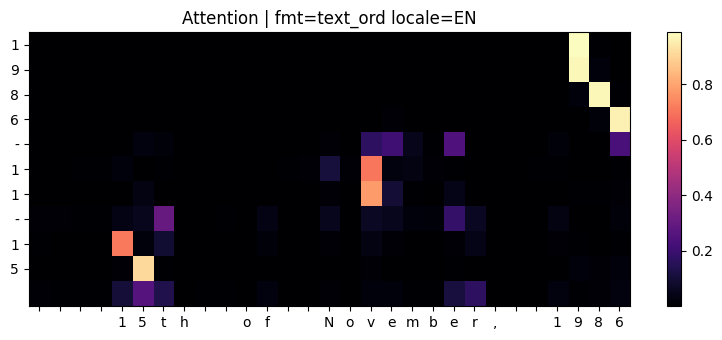


FMT=us_slash | LOCALE=US
src: '04/08/1993  <US>    '
target: 1993-04-08
prediciton: 1993-04-08


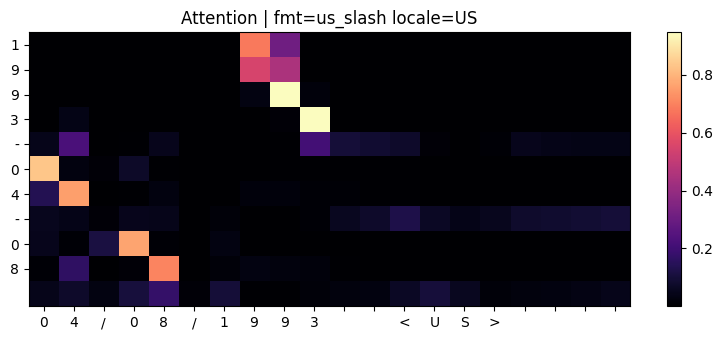


FMT=eu_slash | LOCALE=EU
src: '  23/06/2017  <EU>'
target: 2017-06-23
prediciton: 2017-06-23


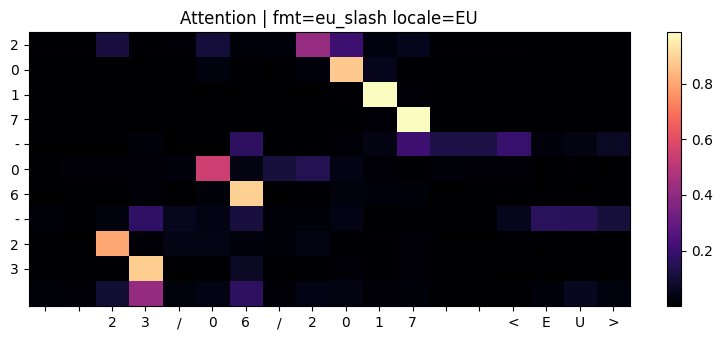

In [11]:
def pick_smth(val_pairs, val_meta, fmt=None, must_contain=None):
    for (src, tgt, _), m in zip(val_pairs, val_meta):
        if fmt is not None and m["fmt"] != fmt:
            continue
        if must_contain is not None and (must_contain not in src):
            continue
        return src, tgt, m

examples = []
examples.append(pick_smth(val_pairs, val_meta, fmt="text_ord"))
examples.append(pick_smth(val_pairs, val_meta, fmt="us_slash", must_contain="<US>"))  # MM/DD/YYYY <US>
examples.append(pick_smth(val_pairs, val_meta, fmt="eu_slash", must_contain="<EU>"))  # DD/MM/YYYY <EU>

for ex in examples:
    if ex is None:
        continue
    src, tgt, m = ex
    pred, attn = greedy_decode_with_attn(model, src)
    print(f"\nFMT={m['fmt']} | LOCALE={m['locale']}")
    print("src:", repr(src))
    print("target:", tgt)
    print("prediciton:", pred)
    plot_attention(src, pred, attn, title=f"Attention | fmt={m['fmt']} locale={m['locale']}")


## Бонус: делаем сравнение Greedy vs Beam search

In [12]:
@torch.no_grad()
def greedy_decode(model, Xsrc, Lsrc, max_len, BOS, EOS, device):
    model.eval()
    enc_out, enc_mask, h = model.encode(Xsrc.to(device), Lsrc.to(device))

    B = Xsrc.size(0)
    y = torch.full((B,), BOS, dtype=torch.long, device=device)

    seq = []
    for _ in range(max_len):
        logits, h, _ = model.decode_step(y, enc_out, enc_mask, h)  # [B,V]
        y = logits.argmax(dim=-1)
        seq.append(y)
    seq = torch.stack(seq, dim=1)  # [B, max_len]
    return seq

In [23]:
@torch.no_grad()
def beam_decode_one(model, xsrc, lsrc, max_len, BOS, EOS, device, beam_size=5, min_out_len=10):
    model.eval()
    xsrc = xsrc.unsqueeze(0).to(device)   # [1,S]
    lsrc = torch.tensor([lsrc], device=device)

    enc_out, enc_mask, h0 = model.encode(xsrc, lsrc)

    # beam: список (seq, logp, last_token, hidden, finished)
    beams = [([BOS], 0.0, BOS, h0, False)]

    for _ in range(max_len):
        candidates = []
        for seq, logp, last_tok, h, finished in beams:
            if finished:
                candidates.append((seq, logp, last_tok, h, True))
                continue

            y_last = torch.tensor([last_tok], device=device)
            logits, h_new, _ = model.decode_step(y_last, enc_out, enc_mask, h)
            log_probs = F.log_softmax(logits[0], dim=-1)  # [V]

            out_len = len(seq) - 1
            if out_len < min_out_len:
                log_probs[EOS] = -1e9

            topv, topi = torch.topk(log_probs, k=beam_size)
            for lp, tok in zip(topv.tolist(), topi.tolist()):
                new_seq = seq + [tok]
                new_logp = logp + lp
                new_finished = (tok == EOS)
                candidates.append((new_seq, new_logp, tok, h_new, new_finished))

        # берём лучшие beam_size по logp (можно добавить length penalty)
        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_size]

        # если все закончились — выходим
        if all(f for *_, f in beams):
            break

    best_seq = beams[0][0]
    # уберём BOS и всё после EOS
    best_seq = best_seq[1:]
    if EOS in best_seq:
        best_seq = best_seq[:best_seq.index(EOS)]
    return best_seq


@torch.no_grad()
def beam_decode(model, Xsrc, Lsrc, max_len, BOS, EOS, device, beam_size=5, min_out_len=10):
    out = []
    for i in range(Xsrc.size(0)):
        seq = beam_decode_one(model, Xsrc[i], int(Lsrc[i].item()),
                              max_len, BOS, EOS, device,
                              beam_size=beam_size, min_out_len=min_out_len)
        out.append(seq)
    return out


In [24]:
@torch.no_grad()
def greedy_str(src_text):
    pred, _ = normalize_date(src_text, return_attn=False)
    return pred

@torch.no_grad()
def beam_str(src_text, beam_size=5):
    Xsrc, Lsrc = encode_batch_var([src_text], SRC_MAXLEN)
    ids = beam_decode_one(model, Xsrc[0], int(Lsrc[0].item()),
                          max_len=TGT_MAXLEN_OUT, BOS=SOS, EOS=EOS,
                          device=DEVICE, beam_size=beam_size, min_out_len=TGT_LEN)
    return decode_ids(ids)

In [25]:
def em_on_pairs(pairs, decoder_fn, max_n=5000):
    ok = 0
    n = min(len(pairs), max_n)
    for i in range(n):
        src, tgt, _ = pairs[i]
        pred = decoder_fn(src)
        ok += int(pred == tgt)
    return ok / n


In [26]:
em_g = em_on_pairs(val_pairs, greedy_str, max_n=5000)
em_b = em_on_pairs(val_pairs, lambda s: beam_str(s, beam_size=5), max_n=5000)

print("Greedy EM:", em_g)
print("Beam5  EM:", em_b)


Greedy EM: 0.9908
Beam5  EM: 0.991
